In [32]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [33]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [34]:
#checking max visibility of file
max_visibility = CV_rows["HourlyVisibility"].max()
print("Maximum HourlyVisibility:", max_visibility)

Maximum HourlyVisibility: 16.0


In [35]:
print(CV_rows.shape)

(14495835, 17)


In [36]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
# the ~ operator is used to negate the condition, so we keep only the rows where the month is not in the specified list
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 17)


In [37]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold in case the csv was cleaned with a different threshold
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

# Filter based on precipitation to see how many rows are removed by the visibility threshold
CV_filtered_rows1 = CV_rows[CV_rows["HourlyPrecipitation"] < 0.03]

print("CV_filtered_rows:", CV_filtered_rows.shape)
print("CV_filtered_rows1:", CV_filtered_rows1.shape)

CV_filtered_rows: (4616544, 17)
CV_filtered_rows1: (6179767, 17)


In [38]:
# Compare rows using their original dataframe indices.
# This identifies the same source rows in both filtered dataframes.

# Find the common indices between the two filtered dataframes
common_idx = CV_filtered_rows.index.intersection(CV_filtered_rows1.index)
# Determine the indices that are only in each of the filtered dataframes
only_in_filtered_rows_idx = CV_filtered_rows.index.difference(CV_filtered_rows1.index)
only_in_filtered_rows1_idx = CV_filtered_rows1.index.difference(CV_filtered_rows.index)

# Create new dataframes for the common rows
common_rows = CV_filtered_rows.loc[common_idx]
# Creat a dataframe for unique rows in each filtered dataframe
only_in_CV_filtered_rows = CV_filtered_rows.loc[only_in_filtered_rows_idx]
only_in_CV_filtered_rows1 = CV_filtered_rows1.loc[only_in_filtered_rows1_idx]

# print the number of rows in each category
print("Rows in both dataframes:", len(common_rows))
print("Rows only in CV_filtered_rows:", len(only_in_CV_filtered_rows))
print("Rows only in CV_filtered_rows1:", len(only_in_CV_filtered_rows1))

# display some of the rows in each category for verification
print("\nRows in both:")
display(common_rows)

print("\nRows only in CV_filtered_rows:")
display(only_in_CV_filtered_rows)

print("\nRows only in CV_filtered_rows1:")
display(only_in_CV_filtered_rows1)

Rows in both dataframes: 4616544
Rows only in CV_filtered_rows: 0
Rows only in CV_filtered_rows1: 1563223

Rows in both:


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.1170,-119.3000,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,16.00,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.1170,-119.3000,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,16.00,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.1170,-119.3000,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,16.00,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.1170,-119.3000,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,16.00,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.1170,-119.3000,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,16.00,225.0,0.5,1941,12,1,4,0,GARDNER AAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14493631,USW00024257,40.5175,-122.2986,2026-03-31 19:53:00,FM-15,11.1,13.9,0.0,16.00,0.0,0.0,2026,3,31,19,53,REDDING AP
14493632,USW00024257,40.5175,-122.2986,2026-03-31 20:53:00,FM-15,12.2,13.3,0.0,16.00,270.0,1.5,2026,3,31,20,53,REDDING AP
14493633,USW00024257,40.5175,-122.2986,2026-03-31 21:49:00,FM-15,12.0,13.0,0.0,14.48,0.0,0.0,2026,3,31,21,49,REDDING AP
14493634,USW00024257,40.5175,-122.2986,2026-03-31 21:53:00,FM-15,12.2,13.3,0.0,14.48,0.0,0.0,2026,3,31,21,53,REDDING AP



Rows only in CV_filtered_rows:


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION



Rows only in CV_filtered_rows1:


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
260,USM00074917,35.11700,-119.3000,1941-12-11 20:00:00,SAO,7.4,9.1,0.0,NaN,23.0,0.5,1941,12,11,20,0,GARDNER AAF
31727,USW00093144,36.31667,-119.4000,1973-01-18 12:00:00,SAO,NaN,NaN,0.0,NaN,180.0,4.1,1973,1,18,12,0,VISALIA MUNICIPAL AP
31728,USW00093144,36.31667,-119.4000,1973-02-01 08:00:00,SAO,NaN,NaN,0.0,NaN,0.0,0.0,1973,2,1,8,0,VISALIA MUNICIPAL AP
31729,USW00093144,36.31667,-119.4000,1973-02-01 10:00:00,SAO,NaN,NaN,0.0,NaN,0.0,0.0,1973,2,1,10,0,VISALIA MUNICIPAL AP
31730,USW00093144,36.31667,-119.4000,1973-02-25 14:00:00,SAO,NaN,10.0,0.0,NaN,220.0,2.0,1973,2,25,14,0,VISALIA MUNICIPAL AP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14493532,USW00024257,40.51750,-122.2986,2026-03-28 00:00:00,SOD,NaN,NaN,0.0,NaN,0.0,0.0,2026,3,28,0,0,REDDING AP
14493557,USW00024257,40.51750,-122.2986,2026-03-29 00:00:00,SOD,NaN,NaN,0.0,NaN,0.0,0.0,2026,3,29,0,0,REDDING AP
14493582,USW00024257,40.51750,-122.2986,2026-03-30 00:00:00,SOD,NaN,NaN,0.0,NaN,0.0,0.0,2026,3,30,0,0,REDDING AP
14493607,USW00024257,40.51750,-122.2986,2026-03-31 00:00:00,SOD,NaN,NaN,0.0,NaN,0.0,0.0,2026,3,31,0,0,REDDING AP


In [39]:
# how many rows in CV_filtered_rows1 have HourlyVisibility < 1
rows_with_low_visibility1 = CV_filtered_rows1[CV_filtered_rows1["HourlyVisibility"] < 1]

# how many rows in CV_filtered_rows have HourlyVisibility < 1
rows_with_low_visibility = CV_filtered_rows[CV_filtered_rows["HourlyVisibility"] < 1]

# compare these two sets of rows to see if they are the same
print("Rows with HourlyVisibility < 1 in CV_filtered_rows1:", rows_with_low_visibility1.shape)
display(rows_with_low_visibility1)
print("Rows with HourlyVisibility < 1 in CV_filtered_rows:", rows_with_low_visibility.shape)
display(rows_with_low_visibility)

Rows with HourlyVisibility < 1 in CV_filtered_rows1: (263418, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
6,USM00074917,35.1170,-119.3000,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,0.200,45.0,0.5,1941,12,1,6,0,GARDNER AAF
7,USM00074917,35.1170,-119.3000,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,0.000,315.0,0.5,1941,12,1,7,0,GARDNER AAF
8,USM00074917,35.1170,-119.3000,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,0.000,90.0,0.5,1941,12,1,8,0,GARDNER AAF
9,USM00074917,35.1170,-119.3000,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,0.200,0.0,0.0,1941,12,1,9,0,GARDNER AAF
10,USM00074917,35.1170,-119.3000,1941-12-01 10:00:00,SAO,12.4,13.5,0.0,0.800,158.0,0.5,1941,12,1,10,0,GARDNER AAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14491976,USW00024257,40.5175,-122.2986,2026-02-12 05:36:00,FM-16,8.9,8.9,0.0,0.402,30.0,2.1,2026,2,12,5,36,REDDING AP
14491977,USW00024257,40.5175,-122.2986,2026-02-12 05:53:00,FM-15,8.3,8.9,0.0,0.402,20.0,2.6,2026,2,12,5,53,REDDING AP
14491978,USW00024257,40.5175,-122.2986,2026-02-12 06:20:00,FM-16,8.3,8.3,0.0,0.805,0.0,0.0,2026,2,12,6,20,REDDING AP
14491979,USW00024257,40.5175,-122.2986,2026-02-12 06:53:00,FM-15,7.8,7.8,0.0,0.402,0.0,0.0,2026,2,12,6,53,REDDING AP


Rows with HourlyVisibility < 1 in CV_filtered_rows: (263418, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
6,USM00074917,35.1170,-119.3000,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,0.200,45.0,0.5,1941,12,1,6,0,GARDNER AAF
7,USM00074917,35.1170,-119.3000,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,0.000,315.0,0.5,1941,12,1,7,0,GARDNER AAF
8,USM00074917,35.1170,-119.3000,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,0.000,90.0,0.5,1941,12,1,8,0,GARDNER AAF
9,USM00074917,35.1170,-119.3000,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,0.200,0.0,0.0,1941,12,1,9,0,GARDNER AAF
10,USM00074917,35.1170,-119.3000,1941-12-01 10:00:00,SAO,12.4,13.5,0.0,0.800,158.0,0.5,1941,12,1,10,0,GARDNER AAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14491976,USW00024257,40.5175,-122.2986,2026-02-12 05:36:00,FM-16,8.9,8.9,0.0,0.402,30.0,2.1,2026,2,12,5,36,REDDING AP
14491977,USW00024257,40.5175,-122.2986,2026-02-12 05:53:00,FM-15,8.3,8.9,0.0,0.402,20.0,2.6,2026,2,12,5,53,REDDING AP
14491978,USW00024257,40.5175,-122.2986,2026-02-12 06:20:00,FM-16,8.3,8.3,0.0,0.805,0.0,0.0,2026,2,12,6,20,REDDING AP
14491979,USW00024257,40.5175,-122.2986,2026-02-12 06:53:00,FM-15,7.8,7.8,0.0,0.402,0.0,0.0,2026,2,12,6,53,REDDING AP


In [40]:
# how many rows in CV_filtered_rows1 have HourlyVisibility < 0.403
rows_with_l4low_visibility1 = CV_filtered_rows1[CV_filtered_rows1["HourlyVisibility"] < 0.403]

# how many rows in CV_filtered_rows have HourlyVisibility < 1
rows_with_l4low_visibility = CV_filtered_rows[CV_filtered_rows["HourlyVisibility"] < 0.403]

# compare these two sets of rows to see if they are the same
print("Rows with HourlyVisibility < 0.403 in CV_filtered_rows1:", rows_with_l4low_visibility1.shape)
display(rows_with_l4low_visibility1)
print("Rows with HourlyVisibility < 0.403 in CV_filtered_rows:", rows_with_l4low_visibility.shape)
display(rows_with_l4low_visibility)

Rows with HourlyVisibility < 0.403 in CV_filtered_rows1: (197023, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
6,USM00074917,35.1170,-119.3000,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,0.200,45.0,0.5,1941,12,1,6,0,GARDNER AAF
7,USM00074917,35.1170,-119.3000,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,0.000,315.0,0.5,1941,12,1,7,0,GARDNER AAF
8,USM00074917,35.1170,-119.3000,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,0.000,90.0,0.5,1941,12,1,8,0,GARDNER AAF
9,USM00074917,35.1170,-119.3000,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,0.200,0.0,0.0,1941,12,1,9,0,GARDNER AAF
27,USM00074917,35.1170,-119.3000,1941-12-02 03:00:00,SAO,10.7,10.7,0.0,0.000,225.0,1.0,1941,12,2,3,0,GARDNER AAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14491840,USW00024257,40.5175,-122.2986,2026-02-09 01:00:00,FM-12,7.8,7.8,0.0,0.400,330.0,1.5,2026,2,9,1,0,REDDING AP
14491976,USW00024257,40.5175,-122.2986,2026-02-12 05:36:00,FM-16,8.9,8.9,0.0,0.402,30.0,2.1,2026,2,12,5,36,REDDING AP
14491977,USW00024257,40.5175,-122.2986,2026-02-12 05:53:00,FM-15,8.3,8.9,0.0,0.402,20.0,2.6,2026,2,12,5,53,REDDING AP
14491979,USW00024257,40.5175,-122.2986,2026-02-12 06:53:00,FM-15,7.8,7.8,0.0,0.402,0.0,0.0,2026,2,12,6,53,REDDING AP


Rows with HourlyVisibility < 0.403 in CV_filtered_rows: (197023, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
6,USM00074917,35.1170,-119.3000,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,0.200,45.0,0.5,1941,12,1,6,0,GARDNER AAF
7,USM00074917,35.1170,-119.3000,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,0.000,315.0,0.5,1941,12,1,7,0,GARDNER AAF
8,USM00074917,35.1170,-119.3000,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,0.000,90.0,0.5,1941,12,1,8,0,GARDNER AAF
9,USM00074917,35.1170,-119.3000,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,0.200,0.0,0.0,1941,12,1,9,0,GARDNER AAF
27,USM00074917,35.1170,-119.3000,1941-12-02 03:00:00,SAO,10.7,10.7,0.0,0.000,225.0,1.0,1941,12,2,3,0,GARDNER AAF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14491840,USW00024257,40.5175,-122.2986,2026-02-09 01:00:00,FM-12,7.8,7.8,0.0,0.400,330.0,1.5,2026,2,9,1,0,REDDING AP
14491976,USW00024257,40.5175,-122.2986,2026-02-12 05:36:00,FM-16,8.9,8.9,0.0,0.402,30.0,2.1,2026,2,12,5,36,REDDING AP
14491977,USW00024257,40.5175,-122.2986,2026-02-12 05:53:00,FM-15,8.3,8.9,0.0,0.402,20.0,2.6,2026,2,12,5,53,REDDING AP
14491979,USW00024257,40.5175,-122.2986,2026-02-12 06:53:00,FM-15,7.8,7.8,0.0,0.402,0.0,0.0,2026,2,12,6,53,REDDING AP


In [41]:
# Display rows that do not meet the minimum rain filter of less than 0.03 inches
CV_rows_rain = CV_rows[CV_rows["HourlyPrecipitation"] >= 0.03]

print("Rows that do not meet minimum rain filter:", CV_rows_rain.shape)
print(CV_rows_rain)

Rows that do not meet minimum rain filter: (225159, 17)
           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
166683    USW00093144  36.31667  -119.4000  2002-11-08 08:00:00       FM-15   
166694    USW00093144  36.31667  -119.4000  2002-11-08 18:00:00       FM-15   
166698    USW00093144  36.31667  -119.4000  2002-11-08 19:15:00        AUTO   
166699    USW00093144  36.31667  -119.4000  2002-11-08 20:00:00       FM-15   
166713    USW00093144  36.31667  -119.4000  2002-11-09 03:00:00       FM-15   
...               ...       ...        ...                  ...         ...   
14493637  USW00024257  40.51750  -122.2986  2026-03-31 23:06:00       FM-16   
14493638  USW00024257  40.51750  -122.2986  2026-03-31 23:18:00       FM-16   
14493639  USW00024257  40.51750  -122.2986  2026-03-31 23:38:00       FM-16   
14493640  USW00024257  40.51750  -122.2986  2026-03-31 23:49:00       FM-15   
14493641  USW00024257  40.51750  -122.2986  2026-03-31 23:53:00       FM-15

In [42]:
#counting days measured per year per station
filtered_days_year = (
    # From CV_filtered_rows
    CV_filtered_rows
    # Drop duplicates based on station, year, month, and day to ensure each day is only counted once
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # group by station and year
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique days
    .size()
    # rename the 'size' column to 'filtered_days'
    .rename(columns={'size': 'filtered_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [43]:
# Find stations with data back to at least 1975
stations_pre1975 = (
    # Group CV_rows by station
    CV_rows.groupby('STATION')['year']
    # find the minimum year 
    .min()
    # Use .loc to filter for stations with data back to at least 1975
    .loc[lambda s: s <= 1975]
    # Get the list of station IDs
    .index
    # Make it a list
    .tolist()
)

# Print list
print(len(stations_pre1975), "stations with data back to at least 1975")
print(stations_pre1975)

# make dateframe with station locations
station_locations = (
    # Filter CV_rows to include only stations with data back to at least 1975
    CV_rows[CV_rows['STATION'].isin(stations_pre1975)]
    # Drop duplicate rows based on the 'STATION' column to ensure each station is represented only once
    .drop_duplicates(subset=['STATION'])
    # Select only the 'STATION', 'LATITUDE', and 'LONGITUDE' columns
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    # Reset the index to ensure a clean DataFrame without the old index
    .reset_index(drop=True)
)

26 stations with data back to at least 1975
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE MUNICIPAL AP', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'VISALIA MUNICIPAL AP', 'WILLIAMS CAA AIRPORT']


In [44]:
# display rows with missing HourlyVisibility
print(CV_rows[CV_rows['HourlyVisibility'].isna()])

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
260       USM00074917  35.11700  -119.3000  1941-12-11 20:00:00         SAO   
31727     USW00093144  36.31667  -119.4000  1973-01-18 12:00:00         SAO   
31728     USW00093144  36.31667  -119.4000  1973-02-01 08:00:00         SAO   
31729     USW00093144  36.31667  -119.4000  1973-02-01 10:00:00         SAO   
31730     USW00093144  36.31667  -119.4000  1973-02-25 14:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14493532  USW00024257  40.51750  -122.2986  2026-03-28 00:00:00         SOD   
14493557  USW00024257  40.51750  -122.2986  2026-03-29 00:00:00         SOD   
14493582  USW00024257  40.51750  -122.2986  2026-03-30 00:00:00         SOD   
14493607  USW00024257  40.51750  -122.2986  2026-03-31 00:00:00         SOD   
14493642  USW00024257  40.51750  -122.2986  2026-03-31 23:59:00         SOM   

          HourlyDewPointTemperature  HourlyDryBulbT

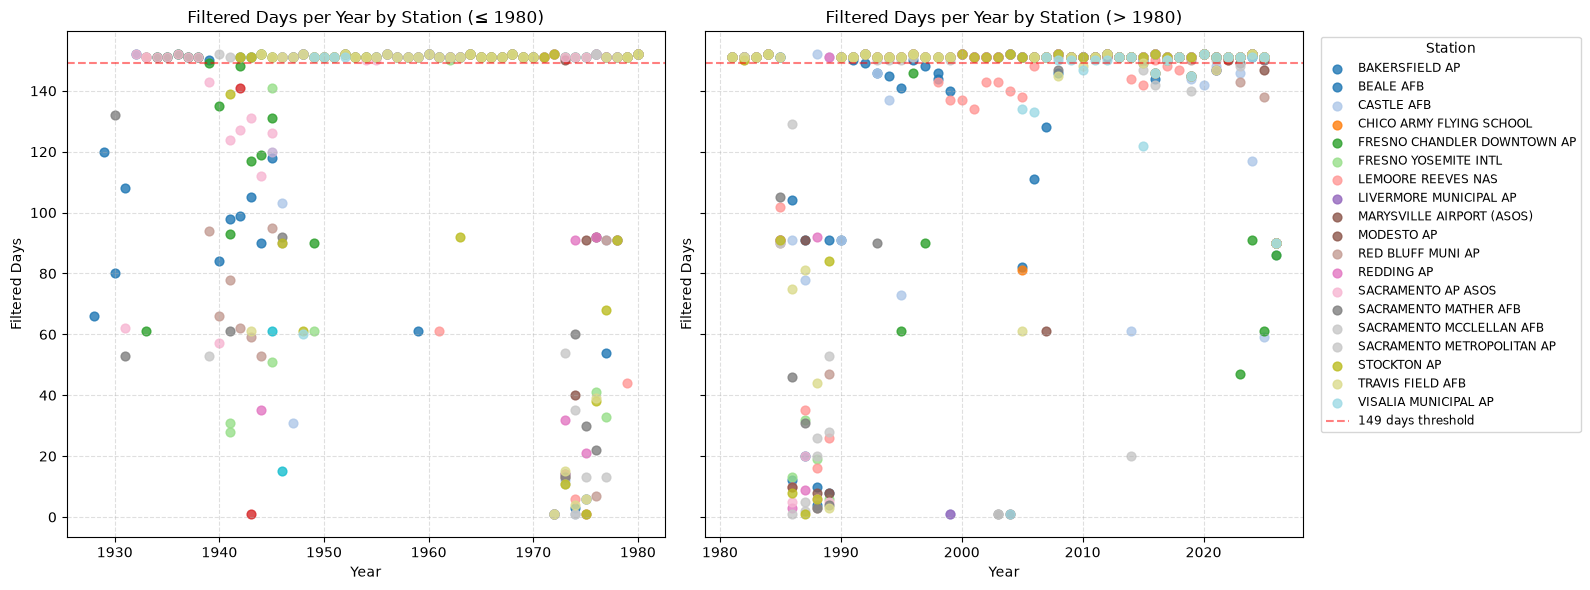

In [45]:
# plot the filtered days per year for the outliers for each station
# doing this in order to see where outlier years are
# use stations with data back to at least 1975
plot_stations = [st for st in stations_pre1975 if st in filtered_days_year['STATION'].unique()]
# define colors for each station using a colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
# create a dictionary mapping each station to its corresponding color
color_map = dict(zip(plot_stations, colors))

# filtered_pre1975 is needed to be distinct from plot_stations
# plot_stations is a list of station names filtered_days_year contains actual numerical data
# including the count of filtered days.
# By filtering filtered_days_year to include only the stations in plot_stations
# we ensure that we are working with the correct subset of data for plotting.
filtered_pre1975 = filtered_days_year[filtered_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Loop through each station and plot the filtered days per year for the two time periods
for station in plot_stations:
    # station_df is defined to hold the filtered data for the current station, sorted by year
    station_df = filtered_pre1975[filtered_pre1975['STATION'] == station].sort_values('year')
    # pre_df is the filtered data for years <= 1980
    pre_df = station_df[station_df['year'] <= 1980]
    # post_df is the filtered data for years > 1980
    post_df = station_df[station_df['year'] > 1980]

# if pre_df is not empty, plot the data for years ≤ 1980 on the first subplot
    if not pre_df.empty:
        # axes[0] = first subplot
        axes[0].scatter(
            # use the 'year' column for the x-axis and 'filtered_days' for the y-axis
            pre_df['year'],
            pre_df['filtered_days'],
            # set s=40 to set size of points
            s=40,
            # set the color of the points based on the station's assigned color
            color=color_map[station],
            # set the transparency of the points to 0.8
            alpha=0.8,
            # label the points with the station name in the legend
            label=station
        )

# if post_df is not empty, plot the data for years > 1980 on the second subplot
    if not post_df.empty:
        # axes[1] = second subplot
        axes[1].scatter(
            # use the 'year' column for the x-axis and 'filtered_days' for the y-axis
            post_df['year'],
            post_df['filtered_days'],
            # set s=40 to set size of points
            s=40,
            # set the color of the points based on the station's assigned color
            color=color_map[station],
            # set the transparency of the points to 0.8
            alpha=0.8,
            # label the points with the station name in the legend
            label=station
        )

# Set titles for plots
axes[0].set_title('Filtered Days per Year by Station (≤ 1980)')
axes[1].set_title('Filtered Days per Year by Station (> 1980)')

# for each subplot
for ax in axes:
    # set x and y labels
    ax.set_xlabel('Year')
    ax.set_ylabel('Filtered Days')
    # enable grid with dashed lines and set transparency
    ax.grid(True, linestyle='--', alpha=0.4)
    # add a horizontal line at y=149 to indicate the cutoff
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

# Add legends to both subplots, placing them outside the plot area
axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# use tight_layout to fit subplots to figure area.
plt.tight_layout()
# display the plots
plt.show()

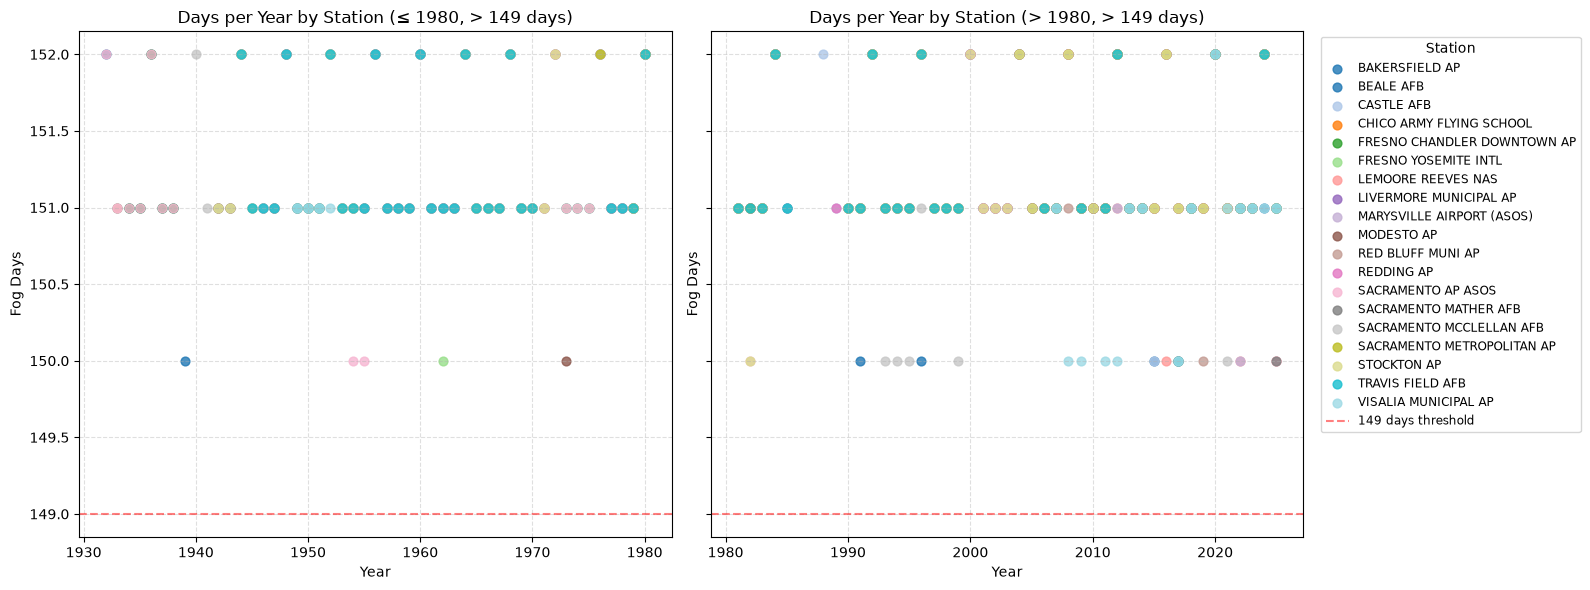

Stations with > 149 days: 22
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE MUNICIPAL AP', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VISALIA MUNICIPAL AP', 'WILLIAMS CAA AIRPORT']


In [46]:
# Remove stations with less than or only 149 days counted
filtered_days_year_filtered = filtered_days_year[filtered_days_year['filtered_days'] > 149]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in filtered_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1975 stations with > 149 fog days
filtered_pre1975_filtered = filtered_days_year_filtered[filtered_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = filtered_pre1975_filtered[filtered_pre1975_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 149 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 149 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 149 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [47]:
# Remove stations with 149 or fewer days counted
fog_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
# Merge the filtered rows with the valid station-year combinations to remove outliers
CV_fog_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 973
CV_fog_rows_no_outliers: (3978541, 17)


In [48]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000 and < 0.403 km
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]
low_vis_rows_1km = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]

# Check the number of rows in each filtered dataframe
print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)

CV_fog_rows_no_outliers with HourlyVisibility < 0.403: (165251, 17)
CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (221673, 17)


In [49]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    # Starting from low_vis_rows (HourlyVisibility < 0.403 km for valid years) 
    low_vis_rows
    # Drop duplicate station-year-month-day combinations
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # Group by station and year to count the number of unique fog days
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique fog days
    .size()
    # rename the 'size' column to 'fog_days'
    .rename(columns={'size': 'fog_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

low_vis_fog_days_year_1km = (
    # Starting from low_vis_rows_1km (HourlyVisibility < 1.000 km for valid years)
    low_vis_rows_1km
    # Drop duplicate station-year-month-day combinations
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # Group by station and year to count the number of unique fog days
    .groupby(['STATION', 'year'], as_index=False)
    # count the number of unique fog days
    .size()
    # rename the 'size' column to 'fog_days'
    .rename(columns={'size': 'fog_days'})
    # sort by station and year
    .sort_values(['STATION', 'year'])
)

In [50]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
# get the stations with at least 30 years of data
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

# print the number of unique station-years for each station in low_vis_fog_days_year
station_year_counts_1km = low_vis_fog_days_year_1km.groupby("STATION")["year"].nunique()
# Determine the stations with at least 30 years of data for the 1km visibility threshold
stations_with_30_years_1km = station_year_counts_1km[station_year_counts_1km >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered_1km = low_vis_fog_days_year_1km[
    low_vis_fog_days_year_1km["STATION"].isin(stations_with_30_years_1km)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years_1km))
print("Filtered low_vis_fog_days_year_1km rows:", low_vis_fog_days_year_filtered_1km.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (785, 3)
Stations kept: 14
Filtered low_vis_fog_days_year_1km rows: (785, 3)


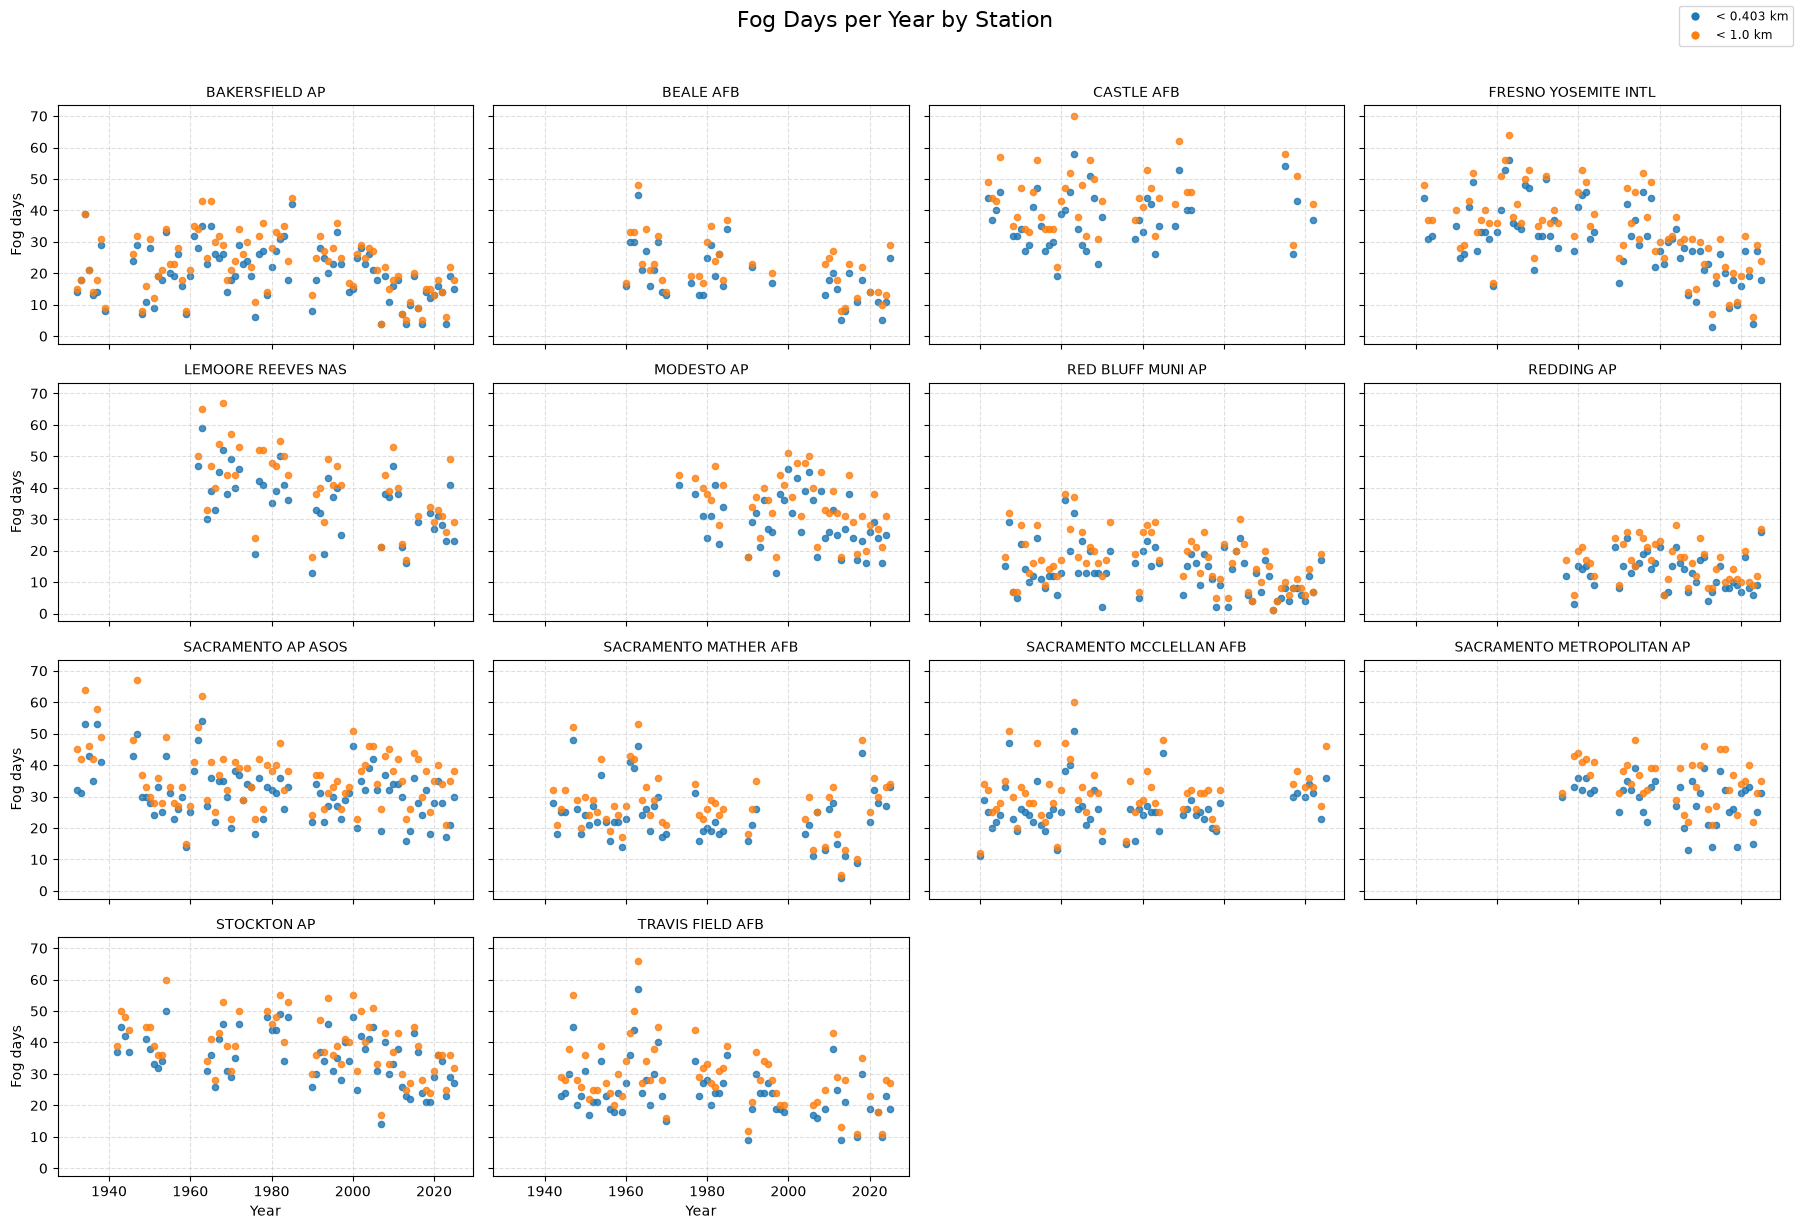

In [53]:
# Determine the unique stations present in both filtered datasets for plotting
# sorted makes it so that the stations are in alphabetical order
stations = sorted(
    set(low_vis_fog_days_year_filtered["STATION"])
    | set(low_vis_fog_days_year_filtered_1km["STATION"])
)

#set number of stations
n_stations = len(stations)
# set number of columns for the subplots
ncols = 4
# Determine number of rows needed for the subplots
nrows = int(np.ceil(n_stations / ncols))

# Make the subplots using rows, columns, and set figure size based on the number of stations
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# flatten axes array to make it easier to iterate over in the loop
axes = axes.flatten()

# Loop through each station and plot the fog days per year for both visibility thresholds
for idx, station in enumerate(stations):
    # Get the current axis for the subplot
    ax = axes[idx]
    # Filter data for the current station
    df_h = low_vis_fog_days_year_filtered[
        low_vis_fog_days_year_filtered["STATION"] == station
    # sort the filtered data by year
    ].sort_values("year")
    # Filter station data for the 1km visibility threshold
    df_1km = low_vis_fog_days_year_filtered_1km[
        low_vis_fog_days_year_filtered_1km["STATION"] == station
    # sort the filtered data by year
    ].sort_values("year")

# If the df is not empty, plot the data for the < 0.403 km visibility threshold
    if not df_h.empty:
        # make the plot a scatter plot with year on the x-axis and fog_days on the y-axis
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            # set size of points to 20
            s=20,
            # set the transparency of the points to 0.8
            alpha=0.8,
            # make the color of the points blue
            color="tab:blue",
            # label blue points for the legend
            label="< 0.403 km"
        )
# If the df is not empty, plot the data for the < 1.0 km visibility threshold
    if not df_1km.empty:
        # make the plot a scatter plot with year on the x-axis and fog_days on the y-axis
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            # set size of points to 20
            s=20,
            # set the transparency of the points to 0.8
            alpha=0.8,
            # make the color of the points orange
            color="tab:orange",
            # label orange points for the legend
            label="< 1.0 km"
        )

# Set the title for each subplot to the station name and set font size
    ax.set_title(station, fontsize=10)
    # Make the grid for each plot have dashed lines and set transparency
    ax.grid(True, linestyle="--", alpha=0.4)

# if the subplot is in the first column, set the y-axis label to "Fog days"
    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
# If the subplot is in the last row, set the x-axis label to "Year"
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

# For station axes not in the first column or last row, remove them from the figure
for ax in axes[n_stations:]:
    fig.delaxes(ax)

# Add a legend
handles = [
    # create a legend entry for the blue points representing < 0.403 km visibility
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=7),
    # create a legend entry for the orange points representing < 1.0 km visibility
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", markersize=7),
]
# add the legend in the upper right corner of the figure with a small font size
fig.legend(handles, ["< 0.403 km", "< 1.0 km"], loc="upper right", fontsize="small")

# Set the overall title for the figure and adjust layout
fig.suptitle("Fog Days per Year by Station", fontsize=16, y=1.02)
# use tight_layout to remove excessive space between subplots 
plt.tight_layout()
plt.show()

In [54]:
# # plot the fog days per year for the filtered stations
# stations = low_vis_fog_days_year_filtered['STATION'].unique()
# n_stations = len(stations)
# ncols = 4
# nrows = int(np.ceil(n_stations / ncols))

# # set up the plot:
# fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
# axes = axes.flatten()

# # plotting for individual stations:
# for idx, station in enumerate(stations):
#     ax = axes[idx]
#     station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
#     ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
#     ax.set_title(station, fontsize=10)
#     ax.grid(True, linestyle='--', alpha=0.4)

#     if idx % ncols == 0:
#         ax.set_ylabel('Fog days')
#     if idx >= (nrows - 1) * ncols:
#         ax.set_xlabel('Year')

# for ax in axes[n_stations:]:
#     fig.delaxes(ax)

# fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

In [ ]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

# Create empty list to hold trend statistics
trend_stats_low_vis_post1980 = []

# Loop through each station in the post-1980 low visibility fog days
for station, station_df in post1980_low_vis.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

    # Use statsmodels to fit a line to each set of station data,
    # Ordinary Least Squares (OLS) regression is used to find the line of best fit
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list. Include...
    trend_stats_low_vis_post1980.append({
        # Station 
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values
trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

# Show what's being printed
print("Post-1980 low-visibility fog-day trend statistics by station:")
# print the first 10 rows of the trend statistics DataFrame
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(10))

# Filter the trend statistics DataFrame to include only stations with significant trends (p < 0.05)
significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
# print the first 10 rows of the significant trends DataFrame
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the post-1980 low visibility fog days by year to analyze overall trends across all stations
annual_low_vis_post1980 = (
    # Starting from the fog days with less than < 1km visibility for years after 1980
    post1980_low_vis
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated post-1980 low visibility fog days
# in order to analyze the overall trend across all stations
model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.586052  0.097954   
0               BAKERSFIELD AP     41      1980      2025 -0.413335  0.081580   
12                 STOCKTON AP     41      1980      2025 -0.337277  0.092439   
6            RED BLUFF MUNI AP     39      1980      2024 -0.264745  0.074327   
1                    BEALE AFB     22      1980      2025 -0.294417  0.079436   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.183439  0.082945   
13            TRAVIS FIELD AFB     30      1980      2025 -0.157279  0.087486   
7                   REDDING AP     42      1980      2025 -0.108758  0.062793   
10    SACRAMENTO MCCLELLAN AFB     23      1980      2025  0.124195  0.075380   
4           LEMOORE REEVES NAS     28      1980      2025 -0.188149  0.117240   
5                   MODESTO AP     40      1980

In [ ]:
# Filter for low visibility fog days after 1980
post1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] >= 1980].copy()

# Create empty list to hold trend statistics for the 1km visibility threshold
trend_stats_low_vis_post1980_1km = []

# Loop through each station in the post-1980 low visibility fog days for the 1km visibility threshold
for station, station_df in post1980_low_vis_1km.groupby("STATION"):
    # Sort the station dataframe by year to ensure proper trend analysis
    station_df = station_df.sort_values("year")
    # Check if the station has at least 3 years of data, if it does, perform the regression
    if len(station_df) < 3:
        continue

# Use statsmodels to fit a line to each set of station data for the 1km visibility threshold
    model = smf.ols("fog_days ~ year", data=station_df).fit()

# Append the trend statistics for each station to the list for the 1km visibility threshold. Include...
    trend_stats_low_vis_post1980_1km.append({
        # Station
        "STATION": station,
        # number of observations (years) for the station
        "n_obs": len(station_df),
        # minimum year of data for the station
        "min_year": station_df["year"].min(),
        # maximum year of data for the station
        "max_year": station_df["year"].max(),
        # slope of the regression line (change in fog days per year)
        "slope": model.params["year"],
        # intercept of the regression line (fog days at "year 0")
        "intercept": model.params["Intercept"],
        # R-squared value of the regression model (proportion of variance explained)
        "r_squared": model.rsquared,
        # p-value for the slope coefficient (statistical significance of the trend)
        "p_value": model.pvalues["year"],
        # standard error of the slope coefficient (uncertainty in the trend estimate)
        "slope_se": model.bse["year"],
        # boolean indicating whether the trend is statistically significant (p < 0.05)
        "trend_significant": model.pvalues["year"] < 0.05,
    })

# Convert the list of trend statistics into a DataFrame and sort by p-values for the 1km visibility threshold
trend_stats_low_vis_post1980_1km = pd.DataFrame(trend_stats_low_vis_post1980_1km).sort_values("p_value")

# Show what's being printed for the 1km visibility threshold
print("Post-1980 low-visibility fog-day trend statistics by station:")
# print the first 10 rows of the trend statistics DataFrame for the 1km visibility threshold
print(trend_stats_low_vis_post1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(10))

# Filter the trend statistics to include only stations with significant trends (p < 0.05) for < 1km visibility
significant_low_vis_post1980_1km = trend_stats_low_vis_post1980_1km[trend_stats_low_vis_post1980_1km["trend_significant"]]
# print the number of stations with significant trends and their corresponding statistics for the 1km visibility threshold
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980_1km)}")
# print the first 10 rows of the significant trends DataFrame for the 1km visibility threshold
print(significant_low_vis_post1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

# Aggregate the post-1980 low visibility fog days by year to analyze overall trends across all stations for the 1km visibility threshold
annual_low_vis_post1980_1km = (
    # Starting from the fog days with less than < 1km visibility for years after 1980
    post1980_low_vis_1km
    # group by year and sum the fog days across all stations
    .groupby("year", as_index=False)["fog_days"]
    # get total number of fog days for each year across all stations
    .sum()
)

# use statsmodels to fit a linear regression model to the annual aggregated post-1980 low visibility fog days for the 1km visibility threshold
# in order to analyze the overall trend across all stations
model_annual_low_vis_post1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_post1980_1km).fit()

# print the summary of the annual aggregated post-1980 low-visibility fog-day trend for the 1km visibility threshold
print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980_1km.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.660703  0.104010   
0               BAKERSFIELD AP     41      1980      2025 -0.491368  0.081271   
6            RED BLUFF MUNI AP     39      1980      2024 -0.387217  0.083805   
12                 STOCKTON AP     41      1980      2025 -0.394927  0.096638   
1                    BEALE AFB     22      1980      2025 -0.298109  0.089178   
4           LEMOORE REEVES NAS     28      1980      2025 -0.331053  0.125770   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.188173  0.083872   
7                   REDDING AP     42      1980      2025 -0.150770  0.069783   
13            TRAVIS FIELD AFB     30      1980      2025 -0.181122  0.101168   
5                   MODESTO AP     40      1980      2024 -0.204019  0.116186   
10    SACRAMENTO MCCLELLAN AFB     23      1980

In [ ]:
# make a list of stations with significant trends for heavy fog days after 1980 (< 0.403 km visibility)
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'STOCKTON AP', 'RED BLUFF MUNI AP', 'BEALE AFB', 'SACRAMENTO METROPOLITAN AP']


In [ ]:
# make a list of stations with significant trends for fog days after 1980 (< 1 km visibility)
stations_significant_low_vis_post1980_1km = significant_low_vis_post1980_1km.loc[
    significant_low_vis_post1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_post1980_1km)

Significant post-1980 low-visibility (<1km) fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB', 'LEMOORE REEVES NAS', 'SACRAMENTO METROPOLITAN AP', 'REDDING AP']


In [ ]:
# Using stations with significant trends for heavy fog days after 1980 (< 0.403 km vis)...
stations = stations_significant_low_vis_post1980

# Using stations with significant trends for fog days after 1980 (< 1 km vis)...
post1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] >= 1980
]
post1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] >= 1980
]

In [30]:
# Plot post-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig = set(stations_significant_low_vis_post1980)      # <0.403 km significant
stations_1km_sig = set(stations_significant_low_vis_post1980_1km)  # <1.0 km significant

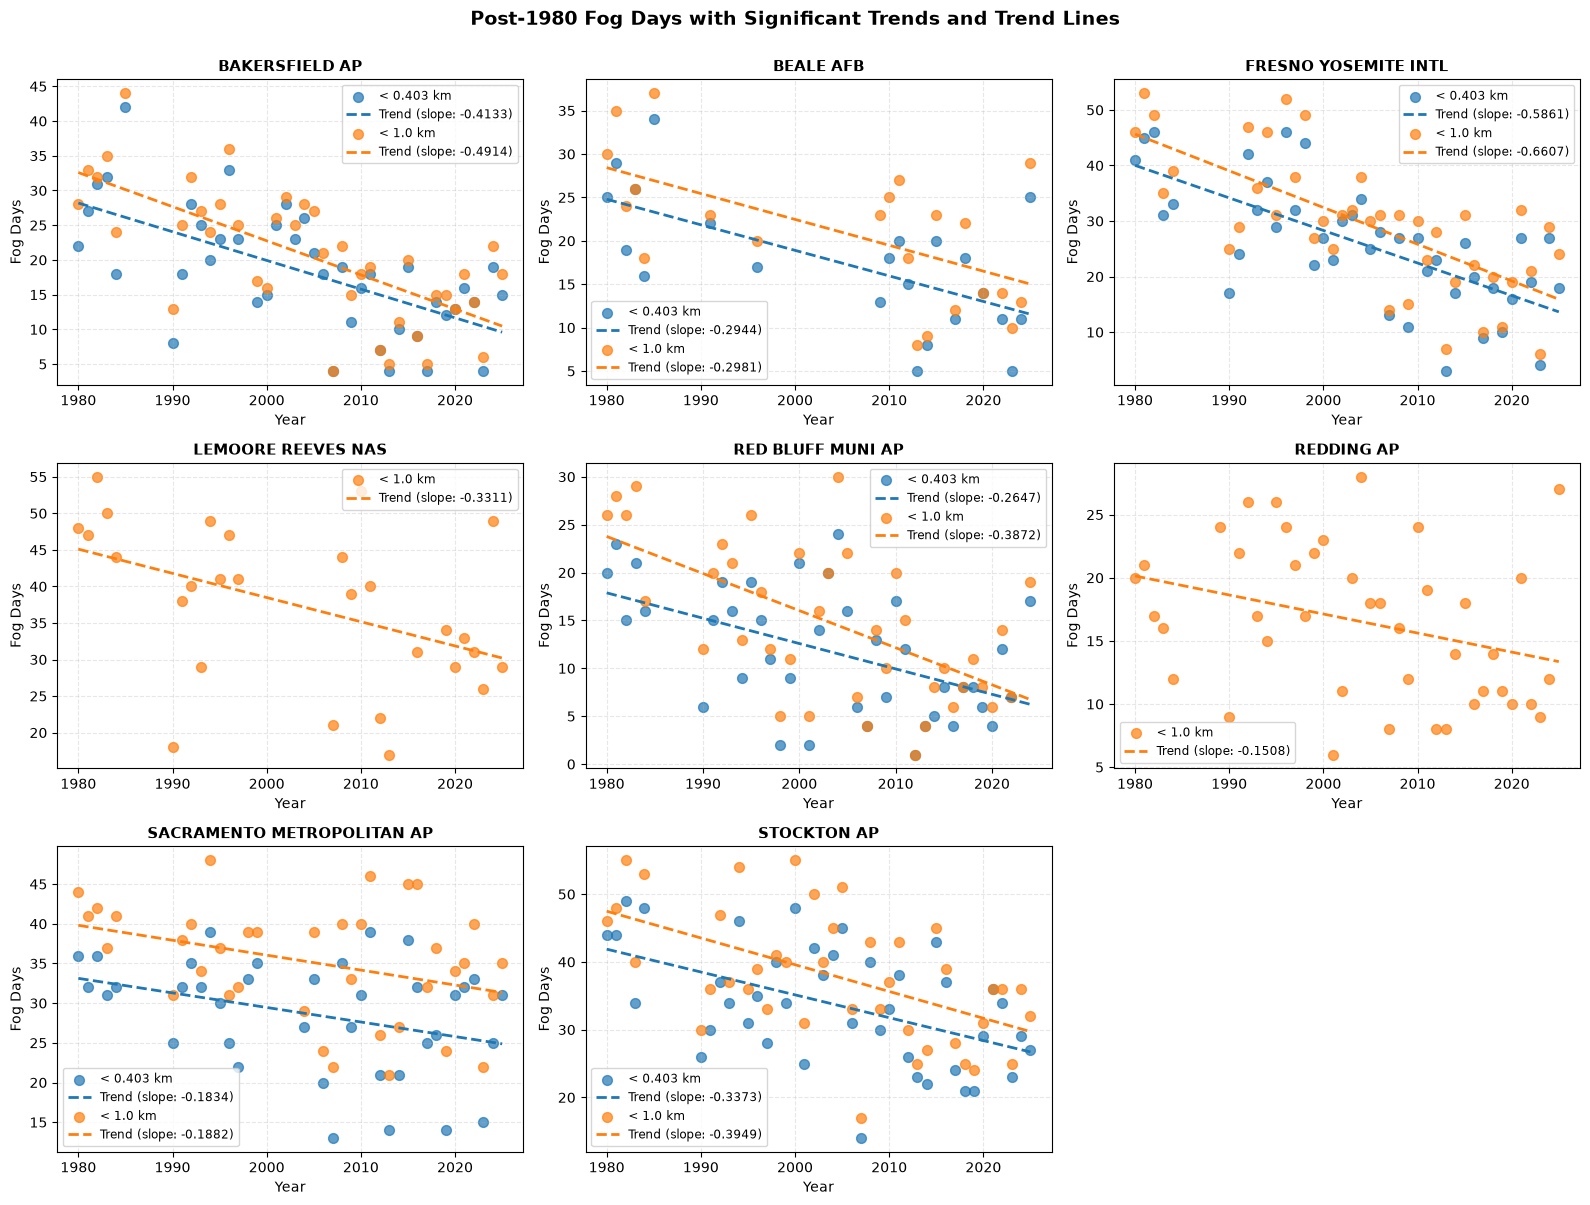

In [31]:
# Create scatterplots with trend lines for stations with significant trends
stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
n_stations = len(stations_to_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, station in enumerate(stations_to_plot):
    ax = axes[idx]
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig
    
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        slope_h = model_h.params["year"]
        trend_line_h = model_h.predict(df_h)
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        slope_1km = model_1km.params["year"]
        trend_line_1km = model_1km.predict(df_1km)
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")
    
    ax.set_title(station, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize="small", loc="best")

# Remove unused axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Post-1980 Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

Now we try the same for fog nights


In [32]:
# Define fog "night" as 18:00-17:59, assigned to the date when the night starts.
# Uses the already-filtered low-visibility fog rows.

# --- <0.403 km threshold ---
night_rows_h = low_vis_rows.copy()
night_rows_h["DATE"] = pd.to_datetime(night_rows_h["DATE"])
night_rows_h["date_only"] = night_rows_h["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis and only stations with at least 30 years of data
# night_rows_h = night_rows_h[night_rows_h["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_h = night_rows_h[night_rows_h["STATION"].isin(stations_with_30_years)].copy()

is_night_h = (night_rows_h["DATE"].dt.hour >= 18) | (night_rows_h["DATE"].dt.hour < 18)

night_rows_h["night_date"] = pd.NaT
night_rows_h.loc[night_rows_h["DATE"].dt.hour >= 18, "night_date"] = night_rows_h["date_only"]
night_rows_h.loc[night_rows_h["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_h["date_only"] - pd.Timedelta(days=1)
)

night_rows_h = night_rows_h[is_night_h].copy()
night_rows_h["night_year"] = night_rows_h["night_date"].dt.year

fog_nights_year_station = (
    night_rows_h.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights = (
    fog_nights_year_station.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("Fog nights per station-year (<0.403 km):")
print(fog_nights_year_station.head())
print("\nAnnual fog nights (<0.403 km):")
print(annual_fog_nights.head())


# --- <1.0 km threshold (optional parallel series) ---
night_rows_1km = low_vis_rows_1km.copy()
night_rows_1km["DATE"] = pd.to_datetime(night_rows_1km["DATE"])
night_rows_1km["date_only"] = night_rows_1km["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis
# night_rows_1km = night_rows_1km[night_rows_1km["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_1km = night_rows_1km[night_rows_1km["STATION"].isin(stations_with_30_years)].copy()

is_night_1km = (night_rows_1km["DATE"].dt.hour >= 18) | (night_rows_1km["DATE"].dt.hour < 18)

night_rows_1km["night_date"] = pd.NaT
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour >= 18, "night_date"] = night_rows_1km["date_only"]
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_1km["date_only"] - pd.Timedelta(days=1)
)

night_rows_1km = night_rows_1km[is_night_1km].copy()
night_rows_1km["night_year"] = night_rows_1km["night_date"].dt.year

fog_nights_year_station_1km = (
    night_rows_1km.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights_1km = (
    fog_nights_year_station_1km.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("\nFog nights per station-year (<1.0 km):")
print(fog_nights_year_station_1km.head())
print("\nAnnual fog nights (<1.0 km):")
print(annual_fog_nights_1km.head())

Fog nights per station-year (<0.403 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1931           1
1  BAKERSFIELD AP  1932          13
2  BAKERSFIELD AP  1933          18
3  BAKERSFIELD AP  1934          38
4  BAKERSFIELD AP  1935          18

Annual fog nights (<0.403 km):
   year  fog_nights
0  1931           2
1  1932          44
2  1933          48
3  1934          92
4  1935          59

Fog nights per station-year (<1.0 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1931           1
1  BAKERSFIELD AP  1932          14
2  BAKERSFIELD AP  1933          18
3  BAKERSFIELD AP  1934          39
4  BAKERSFIELD AP  1935          18

Annual fog nights (<1.0 km):
   year  fog_nights
0  1931           2
1  1932          59
2  1933          58
3  1934         105
4  1935          62


In [33]:
# Determine station-level fog-night trends since 1980
# and plot only significant trends (<0.05 p-value)

trend_stats_nights_h = []
for station, station_df in fog_nights_year_station.groupby("STATION"):
    station_df = station_df.sort_values("year")
    station_df = station_df[station_df["year"] >= 1980]
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_h = pd.DataFrame(trend_stats_nights_h).sort_values("p_value")
significant_nights_h = trend_stats_nights_h[trend_stats_nights_h["trend_significant"]].copy()

print("Significant fog-night trends (<0.403 km):")
print(significant_nights_h[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# Optional parallel analysis for <1.0 km
trend_stats_nights_1km = []
for station, station_df in fog_nights_year_station_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km = pd.DataFrame(trend_stats_nights_1km).sort_values("p_value")
significant_nights_1km = trend_stats_nights_1km[trend_stats_nights_1km["trend_significant"]].copy()

print("\nSignificant fog-night trends (<1.0 km):")
print(significant_nights_1km[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

Significant fog-night trends (<0.403 km):
                       STATION  n_obs     slope   p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.528048  0.000002   0.445539
0               BAKERSFIELD AP     42 -0.379686  0.000047   0.342608
6            RED BLUFF MUNI AP     39 -0.253257  0.001270   0.247560
1                    BEALE AFB     22 -0.276936  0.001427   0.405951
11  SACRAMENTO METROPOLITAN AP     37 -0.216455  0.012078   0.166841
12                 STOCKTON AP     42 -0.267953  0.016357   0.135749
5                   MODESTO AP     40 -0.201722  0.046120   0.100608

Significant fog-night trends (<1.0 km):
                 STATION  n_obs     slope   p_value  r_squared
3   FRESNO YOSEMITE INTL     72 -0.237155  0.000015   0.236259
13      TRAVIS FIELD AFB     60 -0.158404  0.002229   0.150063
6      RED BLUFF MUNI AP     70 -0.124337  0.002238   0.129255
1              BEALE AFB     36 -0.185269  0.003021   0.230814
5             MODESTO AP     43 -0.275630  0.00445

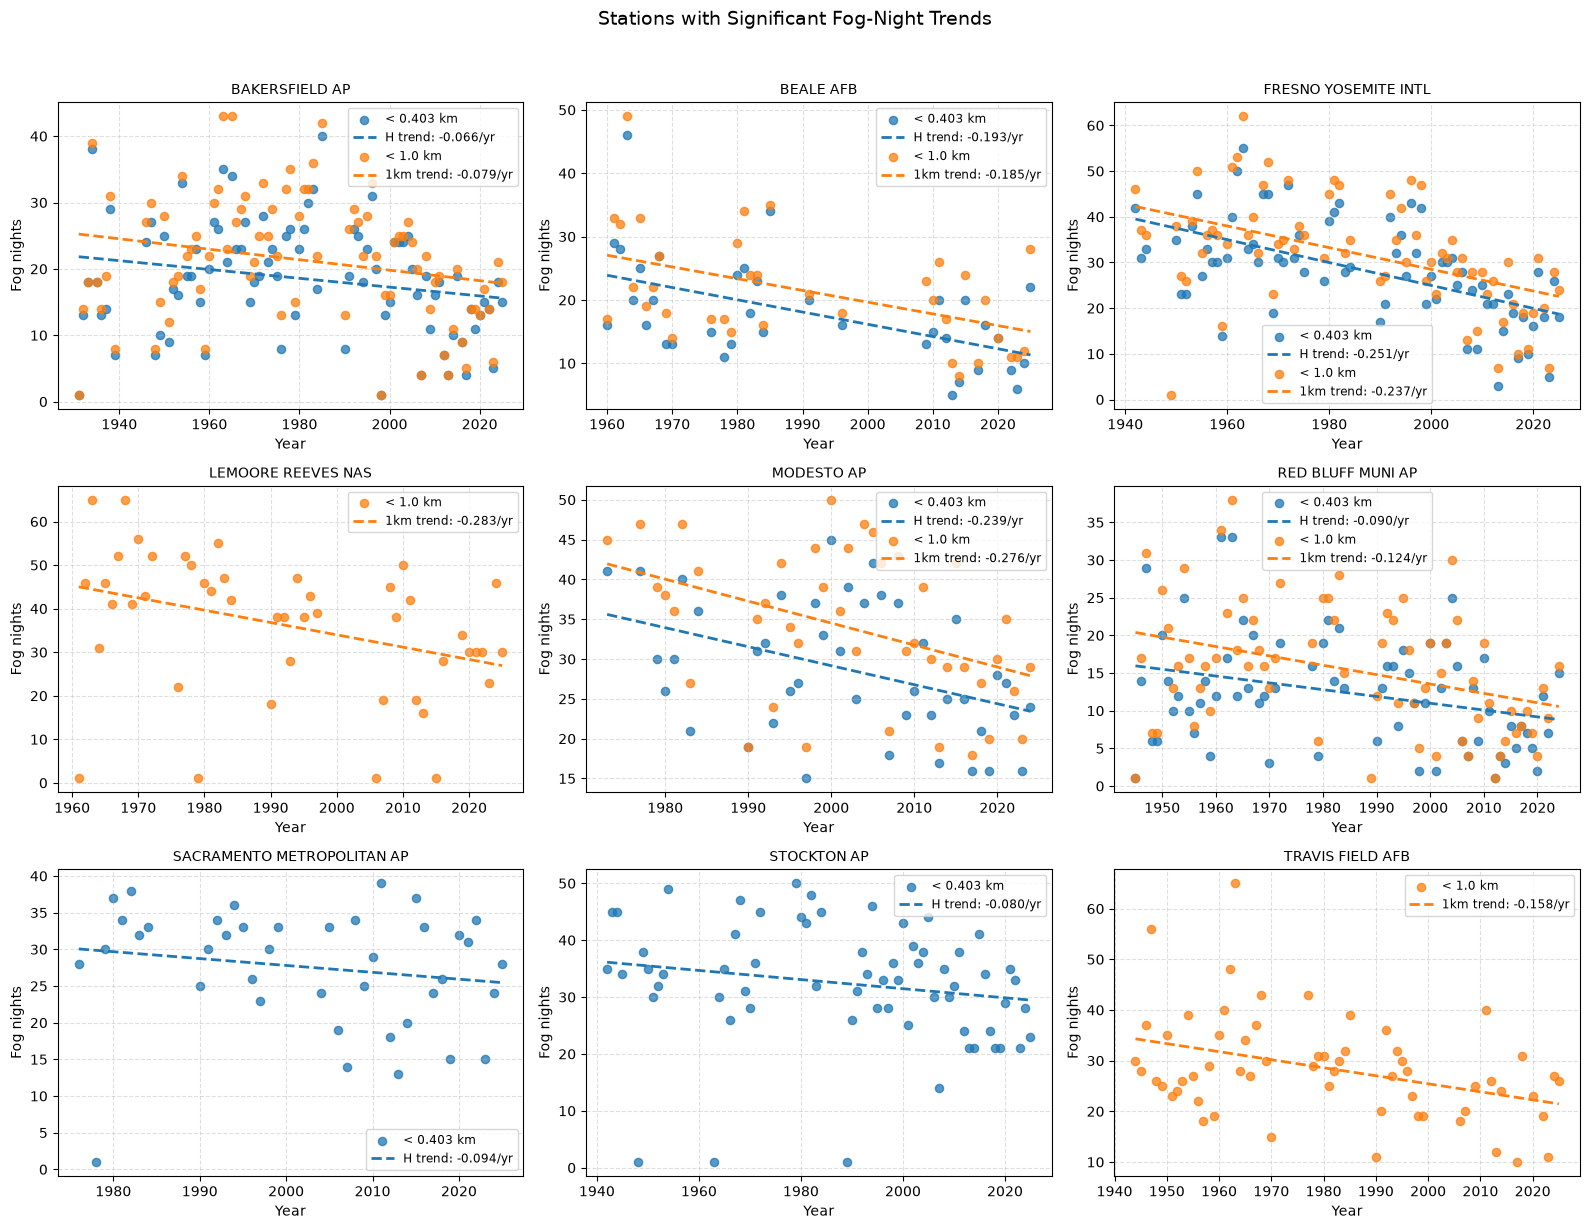

In [34]:
# Plot significant stations with trend lines since 1980 for fog nights (<0.403 km and <1.0 km)

stations_h_sig_nights = set(significant_nights_h["STATION"])
stations_1km_sig_nights = set(significant_nights_1km["STATION"])
stations_to_plot_nights = sorted(stations_h_sig_nights | stations_1km_sig_nights)

if len(stations_to_plot_nights) == 0:
    print("\nNo significant station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights):
        ax = axes[idx]

        df_h = fog_nights_year_station[fog_nights_year_station["STATION"] == station].sort_values("year")
        df_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights and not df_h.empty:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights and not df_1km.empty:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [35]:
# Fog-night trends starting in 1980 only, then plot only significant station trends

post1980_nights_h = fog_nights_year_station[fog_nights_year_station["year"] >= 1980].copy()
post1980_nights_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["year"] >= 1980].copy()

trend_stats_nights_h_post1980 = []
for station, station_df in post1980_nights_h.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_h_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_h_1980.params["year"],
        "intercept": model_h_1980.params["Intercept"],
        "r_squared": model_h_1980.rsquared,
        "p_value": model_h_1980.pvalues["year"],
        "slope_se": model_h_1980.bse["year"],
        "trend_significant": model_h_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_h_post1980 = pd.DataFrame(trend_stats_nights_h_post1980).sort_values("p_value")
significant_nights_h_post1980 = trend_stats_nights_h_post1980[
    trend_stats_nights_h_post1980["trend_significant"]
].copy()

trend_stats_nights_1km_post1980 = []
for station, station_df in post1980_nights_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_1km_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_1km_1980.params["year"],
        "intercept": model_1km_1980.params["Intercept"],
        "r_squared": model_1km_1980.rsquared,
        "p_value": model_1km_1980.pvalues["year"],
        "slope_se": model_1km_1980.bse["year"],
        "trend_significant": model_1km_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km_post1980 = pd.DataFrame(trend_stats_nights_1km_post1980).sort_values("p_value")
significant_nights_1km_post1980 = trend_stats_nights_1km_post1980[
    trend_stats_nights_1km_post1980["trend_significant"]
].copy()

print("Significant post-1980 fog-night trends (<0.403 km):")
print(significant_nights_h_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

print("\nSignificant post-1980 fog-night trends (<1.0 km):")
print(significant_nights_1km_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])


Significant post-1980 fog-night trends (<0.403 km):
                       STATION  n_obs     slope   p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.528048  0.000002   0.445539
0               BAKERSFIELD AP     42 -0.379686  0.000047   0.342608
6            RED BLUFF MUNI AP     39 -0.253257  0.001270   0.247560
1                    BEALE AFB     22 -0.276936  0.001427   0.405951
11  SACRAMENTO METROPOLITAN AP     37 -0.216455  0.012078   0.166841
12                 STOCKTON AP     42 -0.267953  0.016357   0.135749
5                   MODESTO AP     40 -0.201722  0.046120   0.100608

Significant post-1980 fog-night trends (<1.0 km):
                       STATION  n_obs     slope       p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.605373  2.301672e-07   0.500690
0               BAKERSFIELD AP     42 -0.458413  3.873697e-06   0.416994
6            RED BLUFF MUNI AP     40 -0.326096  5.532941e-04   0.272332
1                    BEALE AFB     22 -0.283203  3.85

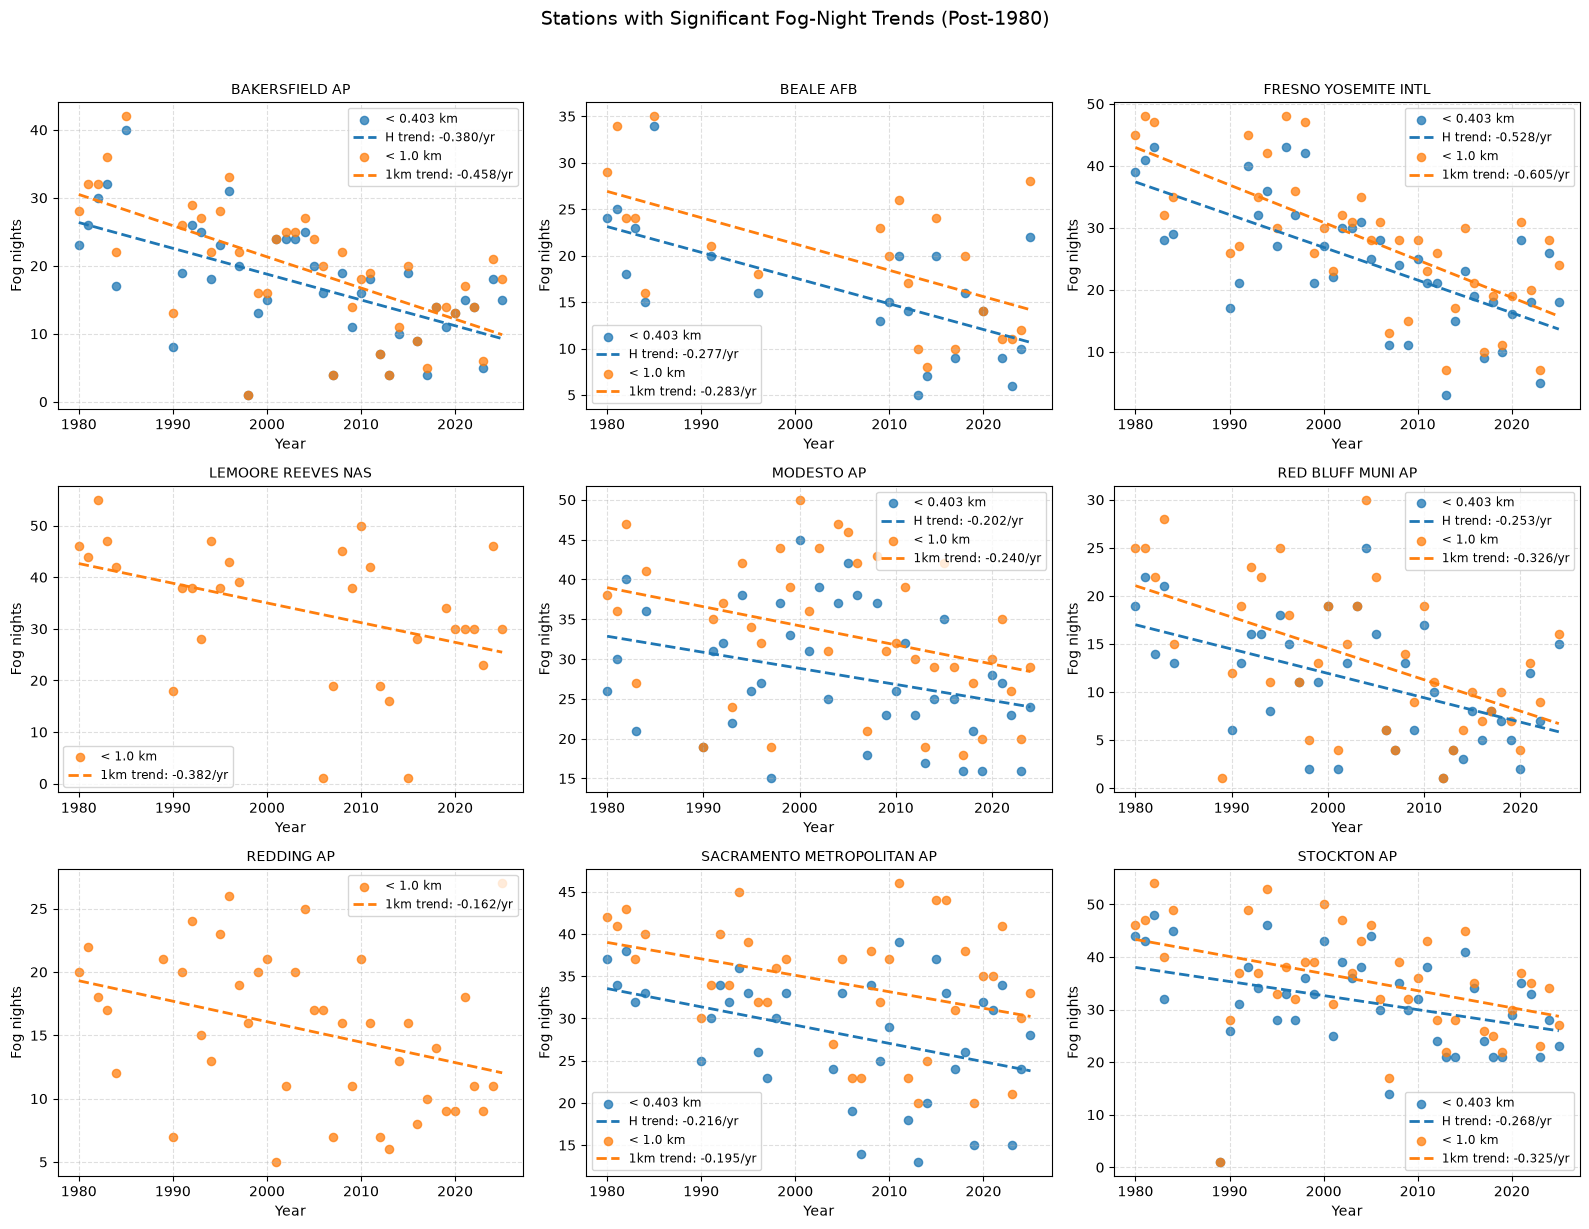

In [36]:

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])
stations_to_plot_nights_post1980 = sorted(stations_h_sig_nights_post1980 | stations_1km_sig_nights_post1980)

if len(stations_to_plot_nights_post1980) == 0:
    print("\nNo significant post-1980 station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights_post1980) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights_post1980):
        ax = axes[idx]

        df_h = post1980_nights_h[post1980_nights_h["STATION"] == station].sort_values("year")
        df_1km = post1980_nights_1km[post1980_nights_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights_post1980 and not df_h.empty:
            model_h_1980 = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h_1980.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h_1980.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights_post1980 and not df_1km.empty:
            model_1km_1980 = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km_1980.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km_1980.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights_post1980):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends (Post-1980)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [37]:
# Compare fog DAYS vs fog NIGHTS (post-1980) and their trend slopes/significance

# --- 1) Average measured fog days/nights per station ---
avg_h_days = post1980_h.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_h"}
)
avg_h_nights = post1980_nights_h.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_h"}
)

avg_1km_days = post1980_1km.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_1km"}
)
avg_1km_nights = post1980_nights_1km.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_1km"}
)

# --- 2) Trend comparison tables (<0.403 km) ---
days_h = trend_stats_low_vis_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_h",
        "p_value": "p_days_h",
        "trend_significant": "sig_days_h",
        "n_obs": "n_days_h",
    }
)

nights_h = trend_stats_nights_h_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_h",
        "p_value": "p_nights_h",
        "trend_significant": "sig_nights_h",
        "n_obs": "n_nights_h",
    }
)

comparison_h = (
    days_h.merge(nights_h, on="STATION", how="outer")
    .merge(avg_h_days, on="STATION", how="left")
    .merge(avg_h_nights, on="STATION", how="left")
)

comparison_h["sig_category_h"] = np.select(
    [
        comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
        comparison_h["sig_days_h"].fillna(False) & ~comparison_h["sig_nights_h"].fillna(False),
        ~comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 3) Trend comparison tables (<1.0 km) ---
days_1km = trend_stats_low_vis_post1980_1km[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_1km",
        "p_value": "p_days_1km",
        "trend_significant": "sig_days_1km",
        "n_obs": "n_days_1km",
    }
)

nights_1km = trend_stats_nights_1km_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_1km",
        "p_value": "p_nights_1km",
        "trend_significant": "sig_nights_1km",
        "n_obs": "n_nights_1km",
    }
)

comparison_1km = (
    days_1km.merge(nights_1km, on="STATION", how="outer")
    .merge(avg_1km_days, on="STATION", how="left")
    .merge(avg_1km_nights, on="STATION", how="left")
)

comparison_1km["sig_category_1km"] = np.select(
    [
        comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
        comparison_1km["sig_days_1km"].fillna(False) & ~comparison_1km["sig_nights_1km"].fillna(False),
        ~comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 4) Print compact outputs ---
print("=== <0.403 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_h.sort_values(["sig_category_h", "STATION"])[
        [
            "STATION",
            "avg_fog_days_h", "avg_fog_nights_h",
            "slope_days_h", "p_days_h", "sig_days_h",
            "slope_nights_h", "p_nights_h", "sig_nights_h",
            "sig_category_h",
        ]
    ]
)

print("\nCounts by significance category (<0.403 km):")
print(comparison_h["sig_category_h"].value_counts())

print("\n=== <1.0 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_1km.sort_values(["sig_category_1km", "STATION"])[
        [
            "STATION",
            "avg_fog_days_1km", "avg_fog_nights_1km",
            "slope_days_1km", "p_days_1km", "sig_days_1km",
            "slope_nights_1km", "p_nights_1km", "sig_nights_1km",
            "sig_category_1km",
        ]
    ]
)

print("\nCounts by significance category (<1.0 km):")
print(comparison_1km["sig_category_1km"].value_counts())

=== <0.403 km: Days vs Nights trend comparison (post-1980) ===
                       STATION  avg_fog_days_h  avg_fog_nights_h  \
0               BAKERSFIELD AP       18.243902         17.285714   
1                    BEALE AFB       17.363636         16.136364   
3         FRESNO YOSEMITE INTL       25.731707         24.512195   
6            RED BLUFF MUNI AP       11.692308         11.076923   
11  SACRAMENTO METROPOLITAN AP       28.594595         28.189189   
12                 STOCKTON AP       33.658537         31.571429   
2                   CASTLE AFB       39.076923         32.000000   
4           LEMOORE REEVES NAS       31.964286         28.566667   
7                   REDDING AP       13.238095         12.238095   
8           SACRAMENTO AP ASOS       29.219512         27.756098   
9        SACRAMENTO MATHER AFB       21.120000         19.115385   
10    SACRAMENTO MCCLELLAN AFB       27.086957         24.125000   
13            TRAVIS FIELD AFB       21.533333       

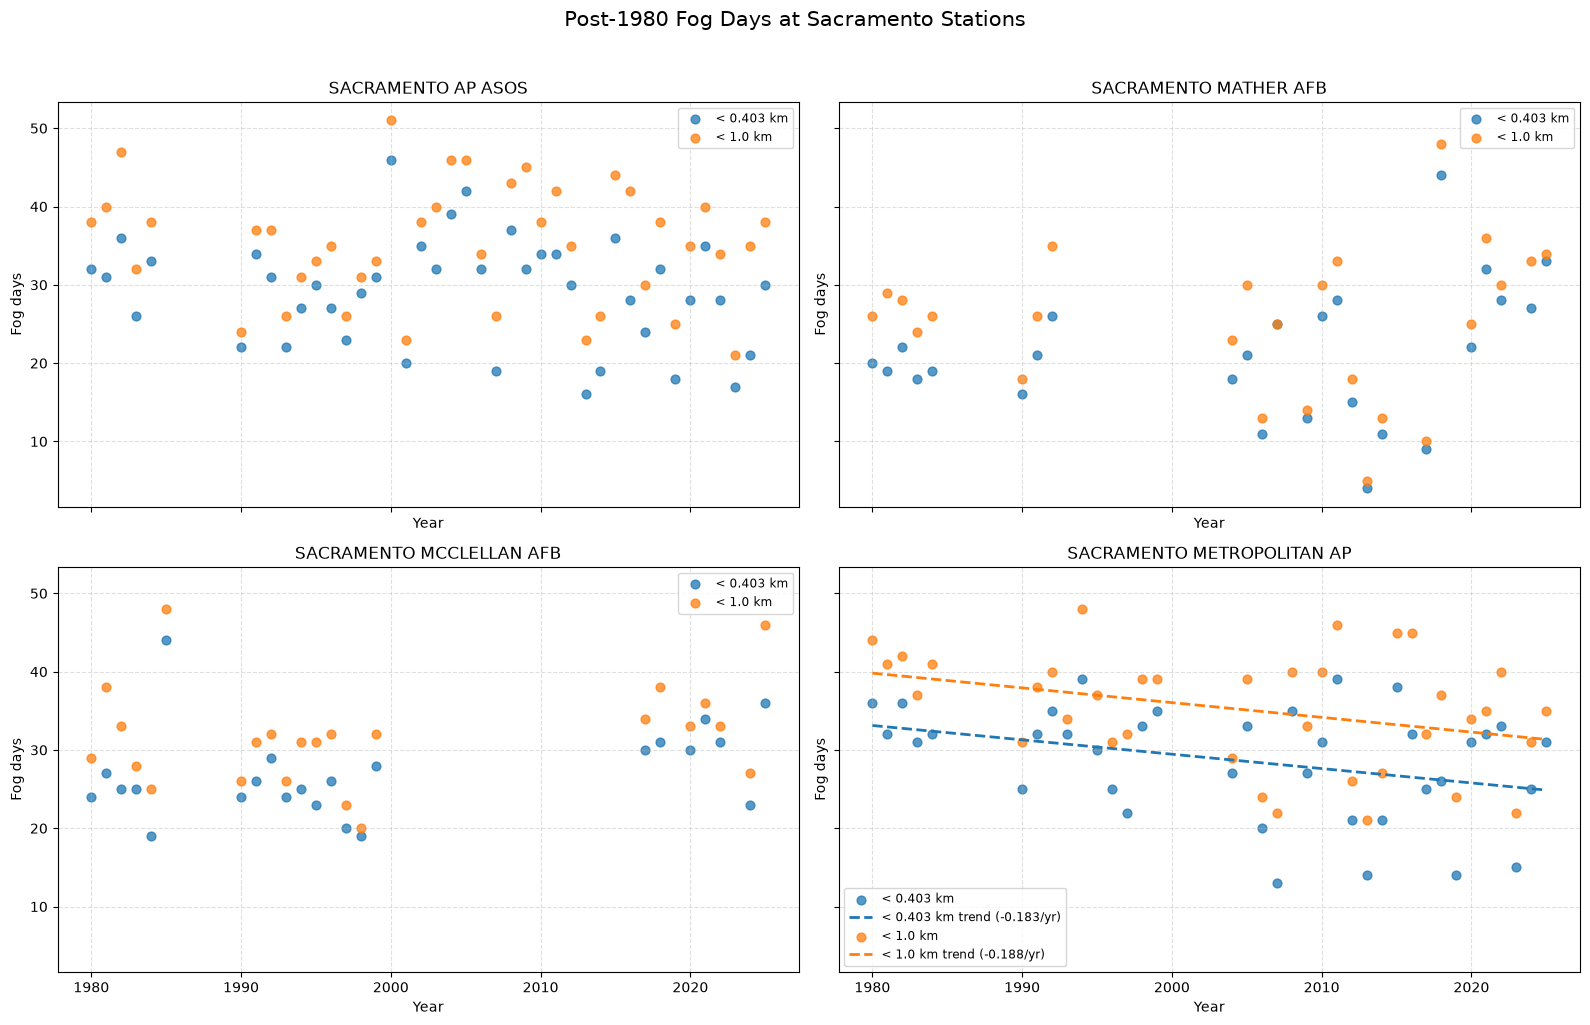

In [38]:
# Scatterplots of post-1980 fog days for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_stations = sorted(
    set(
        post1980_h.loc[
            post1980_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_1km.loc[
            post1980_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

sac_ncols = 2
sac_nrows = int(np.ceil(len(sacramento_stations) / sac_ncols))

fig, axes = plt.subplots(
    sac_nrows,
    sac_ncols,
    figsize=(16, sac_nrows * 5),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, sac_station in enumerate(sacramento_stations):
    ax = axes[idx]

    df_h_sac = post1980_h[
        post1980_h["STATION"] == sac_station
    ].sort_values("year")

    df_1km_sac = post1980_1km[
        post1980_1km["STATION"] == sac_station
    ].sort_values("year")

    if not df_h_sac.empty:
        ax.scatter(
            df_h_sac["year"],
            df_h_sac["fog_days"],
            color="tab:blue",
            alpha=0.75,
            s=40,
            label="< 0.403 km"
        )

        model_h_sac = smf.ols("fog_days ~ year", data=df_h_sac).fit()
        if model_h_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_h_sac["year"],
                model_h_sac.predict(df_h_sac),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"< 0.403 km trend ({model_h_sac.params['year']:.3f}/yr)"
            )

    if not df_1km_sac.empty:
        ax.scatter(
            df_1km_sac["year"],
            df_1km_sac["fog_days"],
            color="tab:orange",
            alpha=0.75,
            s=40,
            label="< 1.0 km"
        )

        model_1km_sac = smf.ols("fog_days ~ year", data=df_1km_sac).fit()
        if model_1km_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_1km_sac["year"],
                model_1km_sac.predict(df_1km_sac),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"< 1.0 km trend ({model_1km_sac.params['year']:.3f}/yr)"
            )

    ax.set_title(sac_station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog days")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Days at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

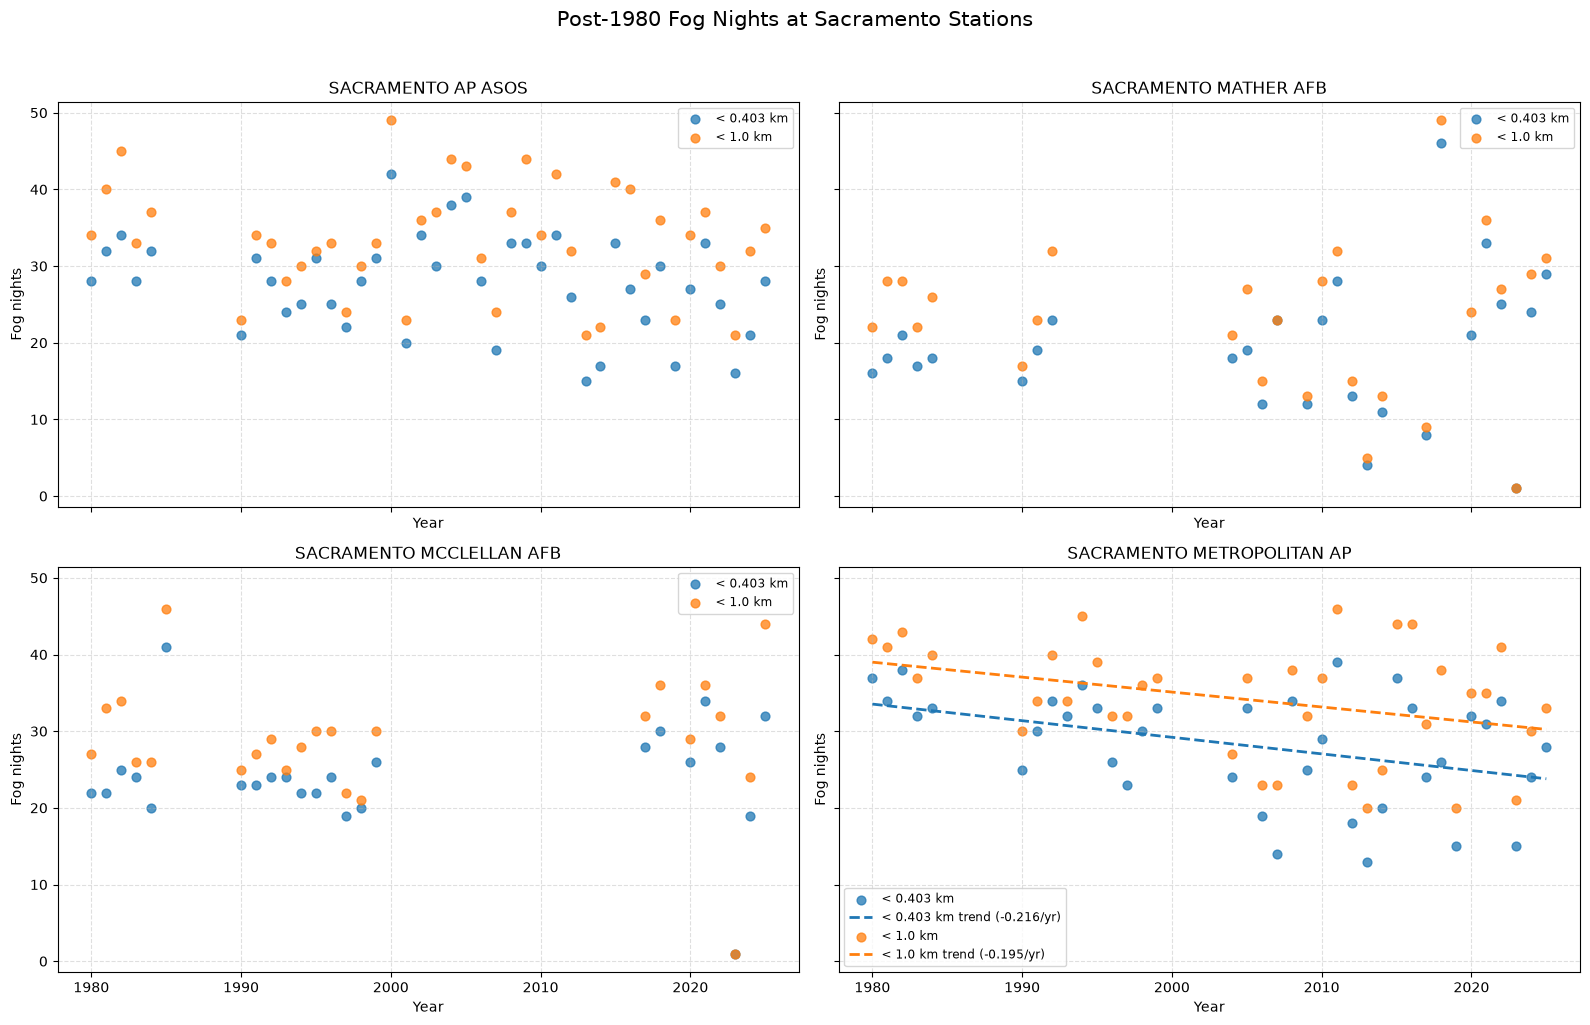

In [39]:
# Scatterplots of post-1980 fog nights for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_night_stations = sorted(
    set(
        post1980_nights_h.loc[
            post1980_nights_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_nights_1km.loc[
            post1980_nights_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])

ncols = 2
nrows = int(np.ceil(len(sacramento_night_stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(16, nrows * 5), sharex=True, sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, station in enumerate(sacramento_night_stations):
    ax = axes[idx]

    df_h = post1980_nights_h[
        post1980_nights_h["STATION"] == station
    ].sort_values("year")

    df_1km = post1980_nights_1km[
        post1980_nights_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"], df_h["fog_nights"],
            color="tab:blue", alpha=0.75, s=40,
            label="< 0.403 km"
        )

        if station in stations_h_sig_nights_post1980:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.plot(
                df_h["year"], model_h.predict(df_h),
                color="tab:blue", linestyle="--", linewidth=2,
                label=f"< 0.403 km trend ({model_h.params['year']:.3f}/yr)"
            )

    if not df_1km.empty:
        ax.scatter(
            df_1km["year"], df_1km["fog_nights"],
            color="tab:orange", alpha=0.75, s=40,
            label="< 1.0 km"
        )

        if station in stations_1km_sig_nights_post1980:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.plot(
                df_1km["year"], model_1km.predict(df_1km),
                color="tab:orange", linestyle="--", linewidth=2,
                label=f"< 1.0 km trend ({model_1km.params['year']:.3f}/yr)"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog nights")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_night_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Nights at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()